In [1]:
import torch
import torch.utils.data as data
import torchvision.transforms as transforms

BATCH_SIZE = 256

dataset_name = "pathmnist"
num_classes = 9

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])
from medmnist.dataset import PathMNIST

# load the data
test_dataset = PathMNIST(split='val', size=224, root="/home/bobsun/cambrige/MedMinist/data", transform=data_transform,
                         download=True)

# encapsulate data into dataloader form
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
den_finetune = torch.load('path_DEN_V6_94.33.pth', map_location=device)
resnet = torch.load('path_resnet.pth', map_location='cpu').to(device)
resnet34 = torch.load('path_resnet34.pth', map_location='cpu').to(device)

Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/pathmnist_224.npz


In [6]:
batch = next(iter(test_loader))
images,labels = batch
images = images.to(device)
labels = labels.to(device)
idx = 0

In [20]:
idx += 1
img_tensor = images[idx].unsqueeze(0)
label = labels[idx]
activation_map_DEN = extract_all_cam(den_finetune, img_tensor, label,
                                         non_negative=1,
                                         negative=-1,
                                         sharpness=1 / num_classes + 0.1,
                                         sharpness_n=0 / num_classes + 0.1,
                                         activation="activation_all",
                                         alpha=0.9)
# activation_map_DEN.shape  = (224, 224)
drop,p_orig = compute_drop_soft(img_tensor, label, resnet34, activation_map_DEN)
similarities = compute_first_7_block_similarity(den_finetune, img_tensor, label)
drop,p_orig,similarities



torch.Size([])


In [3]:
import torch
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# 假设你已经定义或加载：
# den_finetune: 已微调的模型
# resnet34: 用于计算drop的模型（或同一个模型）
# extract_all_cam: 函数用于生成显著性图
# compute_drop_soft: 函数返回(drop, p_orig)
# compute_first_7_block_similarity: 返回7个相似度值的列表
# test_loader: 测试数据集 DataLoader
# device: torch.device('cuda' or 'cpu')
# num_classes: 数据集的类别数

all_drops = []
all_p_orig = []
all_similarities = []

# den_finetune.eval()
resnet34.eval()

count = 0
for images, labels in test_loader:
    count = count + 1
    print(count)
    images = images.to(device)
    labels = labels.to(device)
    
    batch_size = images.size(0)
    for i in range(batch_size):
        img_tensor = images[i].unsqueeze(0)
        label = labels[i]

        # 生成显著性图
        den_finetune.eval() 
        activation_map_DEN = extract_all_cam(
            den_finetune, 
            img_tensor, 
            label,
            non_negative=1,
            negative=-1,
            sharpness=1 / num_classes + 0.1,
            sharpness_n=0 / num_classes + 0.1,
            activation="activation_all",
            alpha=0.9
        )
        den_finetune.eval()
        p_orig = torch.softmax(den_finetune(img_tensor), dim=1)[0, label].item()
        
        # 计算 drop 和 p_orig
        drop, _ = compute_drop_soft(img_tensor, label, resnet34, activation_map_DEN)

        # 计算相似度
        den_finetune.train() 
        sims = compute_first_7_block_similarity(den_finetune, img_tensor, label)

        all_drops.append(drop)
        all_p_orig.append(p_orig)
        all_similarities.append(sims)

# 转为 numpy 数组
all_drops = np.array(all_drops)               # shape: (N, )
all_p_orig = np.array(all_p_orig)             # shape: (N, )
all_similarities = np.array(all_similarities) # shape: (N, 7)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


In [91]:
batch = next(iter(test_loader))
images,labels = batch
idx = -1

In [123]:
def compute_first_7_block_similarity(model, input_tensor, target):
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    model.train()  # 确保前向传播一致
    input_tensor = input_tensor.to(device)
    target = target.to(device)

    # 获取所有的block
    layer_list = []
    for layer_idx in range(1, 5):
        for sublayer_idx in range(2):
            layer_list.append(getattr(model, f"layer{layer_idx}")[sublayer_idx])

    num_blocks = 7
    gradient_records_deep_pred = []
    gradient_records_attention = []

    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    # 计算 deep_pred 梯度
    for block_idx in range(num_blocks):
        optimizer.zero_grad()  # 清理所有参数梯度
        outputs = model(input_tensor)  # outputs shape: [batch_size, num_classes]
        loss = criterion(outputs[block_idx], target)  # 使用整个 outputs 和 target 计算loss
        loss.backward()

        curr_grad = layer_list[block_idx].deep_explain.W.weight.grad.clone()
        gradient_records_deep_pred.append(curr_grad)

    # 计算 attention 梯度
    for block_idx in range(num_blocks):
        optimizer.zero_grad()
        outputs = model(input_tensor)
        loss = criterion(outputs[block_idx + 1], target)
        loss.backward()

        attention_grad = layer_list[block_idx].deep_explain.W.weight.grad.clone()
        gradient_records_attention.append(attention_grad)
    
    optimizer.zero_grad()
    # 计算余弦相似度
    similarities = []
    for block_idx in range(num_blocks):
        grad1 = gradient_records_deep_pred[block_idx]
        grad2 = gradient_records_attention[block_idx]
        similarity = torch.sum(grad1 * grad2) / (torch.norm(grad1) * torch.norm(grad2) + 1e-8)
        similarities.append(similarity.item())

    return similarities

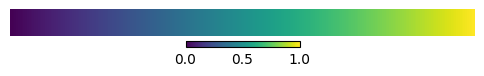

In [198]:
import matplotlib.pyplot as plt
import numpy as np

# 生成渐变数据（大的色带）
gradient = np.linspace(0, 1, 256).reshape(1, -1)  # 水平渐变
gradient = np.vstack((gradient, gradient))  # 扩展为两行，增加视觉宽度

# 创建画布
fig, ax = plt.subplots(figsize=(6, 1))  # 宽 6，高 1
fig.subplots_adjust(bottom=0.5)  # 调整画布布局

# 设置 colormap
cmap = plt.cm.viridis

# 绘制大的色带
cax = ax.imshow(gradient, aspect="auto", cmap=cmap)
ax.set_axis_off()  # 去掉坐标轴

# 在大的色带上添加 colorbar 并设置刻度位置
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax, orientation='horizontal', ticks=[0, 0.5, 1.0])
cbar.ax.tick_params(labelsize=10, length=0)  # 设置刻度标签大小，去掉刻度线
cbar.ax.set_xticklabels(['0.0', '0.5', '1.0'])  # 设置刻度标签内容

# 保存图像
# plt.savefig("horizontal_colorbar_fixed.png", dpi=300, bbox_inches='tight')
plt.show()

24


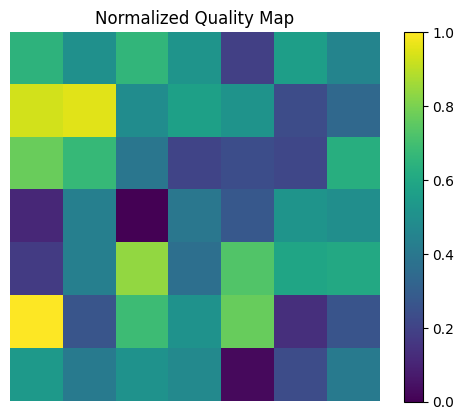

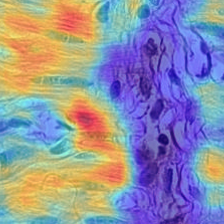

In [195]:
idx = 24
print(idx)
#14 24 25

images = images.to(device)
labels = labels.to(device)
img_tensor = images[idx].unsqueeze(0)
label = labels[idx]
img_tensor_unorm = img_tensor * 0.5 + 0.5
res = 7
quality = np.zeros((res, res))
for i in range(res):
    for j in range(res):
        masked_image = mask_image_with_mean(img_tensor_unorm.squeeze(), grid_size=res, block_coords=(i, j))
        img_tensor_for_model = masked_image * 2.0 - 1.0
        den_finetune.train() 
        sims = compute_first_7_block_similarity(den_finetune, img_tensor_for_model.unsqueeze(0), label)
        weights = [0.5,0.55,0.6,0.65,0.7,0.75,0.8]
        weights = [1,1,1,1,1,1,1]
        weighted_sum = sum(v * w for v, w in zip(weights, sims))
        quality[i,j] =  weighted_sum
        
quality_min = np.min(quality)
quality_max = np.max(quality)
quality_norm = (quality - quality_min) / (quality_max - quality_min)

# 可视化归一化后的结果
plt.imshow(quality_norm, cmap='viridis')
plt.colorbar()
plt.axis("off")
plt.title("Normalized Quality Map")
plt.show()

den_finetune = torch.load('path_DEN_V6_94.33.pth', map_location=device)
activation_map_DEN = extract_all_cam(den_finetune, img_tensor, label,
                                     non_negative=1,
                                     negative=-0.5,
                                     sharpness=1 / num_classes + 0.1,
                                     sharpness_n=1 / num_classes + 0.1,
                                     activation="activation_all",
                                     alpha=0.8)

img = img_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
img = (img * 0.5 + 0.5) * 255
img = img.astype(np.uint8)
from torchcam.utils import overlay_mask
from PIL import Image
overlay_image = overlay_mask(Image.fromarray(img), Image.fromarray(activation_map_DEN, mode='F'), alpha=0.5)
overlay_image



# 显示图片
# img_tensor = img_tensor.squeeze()
# image_np =mask_image_with_mean(img_tensor*0.5+0.5,grid_size=7, block_coords=(0, 0)).permute(1, 2, 0).cpu().numpy()
# image_np = image_np #* 0.5+0.5
# plt.imshow(image_np)
# image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
# plt.show()

In [4]:
from sklearn.feature_selection import mutual_info_regression
import numpy as np
# 计算相关性
# 1. 相似度与drop的相关性
print("相似度与drop相关性：")
for block_idx in range(7):
    similarity_values = all_similarities[:, block_idx]
    corr_drop, p_drop = pearsonr(similarity_values, all_drops)
    print(f"Block {block_idx+1}: correlation with drop = {corr_drop:.4f}, p={p_drop:.4f}")

# 2. 相似度与p_orig的相关性
print("\n相似度与p_orig相关性：")
for block_idx in range(7):
    similarity_values = all_similarities[:, block_idx]
    corr_p, p_p = pearsonr(similarity_values, all_p_orig)
    print(f"Block {block_idx+1}: correlation with p_orig = {corr_p:.4f}, p={p_p:.4f}")

# 3. drop与p_orig的相关性
corr_dp, p_dp = pearsonr(all_drops, all_p_orig)
print(f"\nDrop与p_orig的相关性: correlation = {corr_dp:.4f}, p={p_dp:.4f}")

# 可视化相似度与drop的相关性（示例：显示每个block与drop的相关性）
blocks = [f"Block {i+1}" for i in range(7)]
correlation_values_drop = [pearsonr(all_similarities[:, i], all_drops)[0] for i in range(7)]

print("相似度与drop的互信息：")
for block_idx in range(7):
    similarity_values = all_similarities[:, block_idx].reshape(-1, 1)  # sklearn要求输入为二维
    mi_drop = mutual_info_regression(similarity_values, all_drops)
    print(f"Block {block_idx+1}: Mutual Information with drop = {mi_drop[0]:.4f}")

print("\n相似度与p_orig的互信息：")
for block_idx in range(7):
    similarity_values = all_similarities[:, block_idx].reshape(-1, 1)
    mi_p_orig = mutual_info_regression(similarity_values, all_p_orig)
    print(f"Block {block_idx+1}: Mutual Information with p_orig = {mi_p_orig[0]:.4f}")

mi_dp = mutual_info_regression(all_drops.reshape(-1, 1), all_p_orig)
print(f"\nDrop与p_orig的互信息: Mutual Information = {mi_dp[0]:.4f}")



相似度与drop相关性：
Block 1: correlation with drop = -0.0800, p=0.0000
Block 2: correlation with drop = 0.0112, p=0.2607
Block 3: correlation with drop = -0.0731, p=0.0000
Block 4: correlation with drop = -0.0090, p=0.3703
Block 5: correlation with drop = 0.1710, p=0.0000
Block 6: correlation with drop = 0.0578, p=0.0000
Block 7: correlation with drop = 0.1211, p=0.0000

相似度与p_orig相关性：
Block 1: correlation with p_orig = -0.1205, p=0.0000
Block 2: correlation with p_orig = 0.1024, p=0.0000
Block 3: correlation with p_orig = 0.1206, p=0.0000
Block 4: correlation with p_orig = 0.0281, p=0.0049
Block 5: correlation with p_orig = -0.0274, p=0.0061
Block 6: correlation with p_orig = -0.1562, p=0.0000
Block 7: correlation with p_orig = -0.1302, p=0.0000

Drop与p_orig的相关性: correlation = -0.1764, p=0.0000
相似度与drop的互信息：
Block 1: Mutual Information with drop = 0.3090
Block 2: Mutual Information with drop = 0.0193
Block 3: Mutual Information with drop = 0.2775
Block 4: Mutual Information with drop = 0.000

In [81]:
from torch import nn
import torch
from torchcam.utils import overlay_mask
from PIL import Image
import cv2
import numpy as np
import torch.nn.functional as F

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def compute_drop_soft(img_tensor, label, model, cam):
    """
    计算 drop_soft 值。
    """
    img_tensor = img_tensor.to(device)
    label = torch.tensor([label], device=device) if isinstance(label, int) else label.to(device)
    cam = torch.from_numpy(cam).to(device)
    # 原始预测概率 p_orig
    model.train()
    with torch.no_grad():
        outputs_orig = model(img_tensor)
        p_orig = torch.softmax(outputs_orig, dim=1)[0, label].item()

    # 计算均值图像
    img_mean = img_tensor.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]

    # Soft替换
    img_soft_masked = img_tensor.clone().to(device)
    img_soft_masked = img_soft_masked * (1 - cam) + img_mean * cam

    # 计算 p_soft_masked
    with torch.no_grad():
        outputs_soft = model(img_soft_masked)
        p_soft_masked = torch.softmax(outputs_soft, dim=1)[0, label].item()

    drop_soft = max(0, (p_orig - p_soft_masked) / p_orig)

    return drop_soft,p_orig





def test(model, test_loader):
    model.eval()
    test_total = 0
    test_correct = 0
    # Disable gradient calculation for faster inference
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long()
            # Forward pass
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            # Update correct and total counts
            test_total += targets.size(0)
            test_correct += (predicted == targets).sum().item()
    # Calculate accuracy
    test_accuracy = 100 * test_correct / test_total
    print(f'Test Accuracy: {test_accuracy:.2f}%')
    return test_accuracy

def extract_all_cam(model, img_tensor, label, non_negative=1, negative=0, sharpness=0, sharpness_n=0,
                    activation="activation", alpha=1):
    output = model(img_tensor)
    original_image = img_tensor.cpu().squeeze().numpy()
    if original_image.ndim == 2:  # 单通道 (H, W)
        display_image = (original_image * 0.5 + 0.5) * 255  # 转换到 [0, 255]
        input_image = np.stack([display_image] * 3, axis=-1)  # 转为三通道
    elif original_image.ndim == 3:  # 多通道 (C, H, W)
        input_image = (original_image.transpose(1, 2, 0) * 0.5 + 0.5) * 255

    input_image = input_image.astype('uint8')

    cam_list = []
    for i in range(1, 5):  # 遍历网络的不同层
        for j in range(2):  # 遍历层的分支
            pred_fc = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'pred_fc').weight
            W = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'W').weight
            weight = pred_fc @ W
            feature_map = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), activation)
            logit = getattr(getattr(getattr(model, f'layer{i}')[j], 'deep_explain'), 'deep_pred')
            probabilities = F.softmax(logit, dim=1).cpu().detach().numpy()[0]
            predicted_class_idx = np.argmax(probabilities)
            _, activation_map = generate_cam_with_overlay(weight, feature_map, label, input_image,
                                                          non_negative, negative, sharpness, sharpness_n)
            cam_list.append(activation_map)

    # 按权重调整各层的CAM并计算全局CAM
    for i in range(len(cam_list)):
        cam_list[i] = cam_list[i] * (alpha ** (len(cam_list) - (i + 1)))

    all_cam = np.sum(cam_list, axis=0)
    all_cam = (all_cam - all_cam.min()) / (all_cam.max() - all_cam.min())  # 归一化处理

    return all_cam

def get_weight_with_sharpness(full_weight, y, sharpness, sharpness_n):
    # 确保 full_weight 是 PyTorch 张量
    full_weight_pt = full_weight
    weight_pt = full_weight_pt[y]

    # 转换为 NumPy 数组
    full_weight_np = full_weight_pt
    weight_np = weight_pt

    # 处理负向权重
    full_weight_n = -full_weight_np.copy()
    weight_n = -weight_np.copy()

    # 正向权重处理
    full_weight_np[full_weight_np < 0] = 0
    norm = np.sum(full_weight_np, axis=0)
    weight_np[weight_np < 0] = 0
    alpha = weight_np / (norm + 1e-8)
    weight_np[alpha < sharpness] = 0

    # 负向权重处理
    full_weight_n[full_weight_n < 0] = 0
    norm_n = np.sum(full_weight_n, axis=0)
    weight_n[weight_n < 0] = 0
    alpha_n = weight_n / (norm_n + 1e-8)
    weight_n[alpha_n < sharpness_n] = 0

    # 最终权重
    final_weight = weight_np - weight_n

    return final_weight


def generate_cam_with_overlay(fc_weights, feature_map, class_idx, input_image, non_negative=1.0, negative=0,
                              sharpness=0, sharpness_n=0):
    # print("class_idx:",class_idx)
    weights = fc_weights[class_idx].cpu().detach().numpy()
    if (sharpness > 0 or sharpness_n > 0):
        weights = get_weight_with_sharpness(fc_weights.cpu().detach().numpy(), class_idx, sharpness, sharpness_n)
    B, C, H, W = feature_map.shape
    feature_map = feature_map.cpu().detach().numpy()

    # 计算正向 CAM
    weights_positive = np.clip(weights, a_min=0, a_max=None)
    weights_negative = np.clip(-weights, a_min=0, a_max=None)
    weights_final = non_negative * weights_positive + negative * weights_negative
    cam_positive = np.sum(weights_final[:, None, None] * feature_map[0], axis=0)
    cam_return = cam_positive.copy()

    # 归一化 CAM
    min_val = np.percentile(cam_positive, 1)
    max_val = np.percentile(cam_positive, 99)
    cam_positive = (cam_positive - min_val) / (max_val - min_val)
    cam_positive[cam_positive < 0.1] = 0
    cam_positive[cam_positive > 1.0] = 1.0
    cam_positive_resized = cv2.resize(cam_positive, (input_image.shape[1], input_image.shape[0]))
    cam_return = cv2.resize(cam_return, (input_image.shape[1], input_image.shape[0]))

    # 将激活图转换为 PIL Image 格式
    activation_map = Image.fromarray(cam_positive_resized, mode='F')

    # 使用 overlay_mask 叠加
    overlay_image = overlay_mask(Image.fromarray(input_image), activation_map, alpha=0.5)

    return overlay_image, cam_return